![lop](../../images/logo_diive1_128px.png)

<span style='font-size:32px; display:block;'>
<b>
    Outlier detection: Hampel filter
</b>
</span>

---
**Notebook version**: `1` (17 Aug 2024)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)  

</br>

# **Description**

- Identify outliers in a sliding window based on the Hampel filter.
- The Hampel filter employs a moving window and utilizes the Median Absolute Deviation (MAD) as a measure of data variability. MAD is calculated by taking the median of the absolute differences between each data point and the median of the moving window.
- Implemented from [sktime](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.transformations.series.outlier_detection.HampelFilter.html)
- Flag contains `0` and `2`, whereby `0=OK` and `2=outlier`
- This example uses air temperature for one month and adds impulse noise to add some spikes to the data before testing

</br>

# **Imports**

In [1]:
import importlib.metadata
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd

import diive.configs.exampledata as ed
from diive.core.plotting.timeseries import TimeSeries
from diive.pkgs.createvar.noise import add_impulse_noise
from diive.pkgs.outlierdetection.hampel import Hampel

warnings.filterwarnings('ignore')
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.85.0


</br>

# **Docstring**

In [2]:
help(Hampel)

Help on function Hampel in module diive.pkgs.outlierdetection.hampel:

Hampel(series: pandas.core.series.Series, window_length: int = 10, n_sigma: float = 5, k: float = 1.4826, idstr: str = None, showplot: bool = False, verbose: bool = False)



</br>

# **Load example data**

## Load and prepare data (one month)

In [14]:
df = pd.read_csv(r"I:\TMP\DAV_dyco\2-OUT_LAG\1-3__input_files__time_lags_overview\1_segments_found_lag_times_after_iteration-1.csv", index_col=1)
df


,Unnamed: 0,start,end,numvals_W_[HS50-B]_TURB,numvals_CH4_DRY_[QCL-C]_TURB,lagsearch_start,lagsearch_end,iteration,PEAK-COVABSMAX_SHIFT,PEAK-COVABSMAX_COV,PEAK-COVABSMAX_TIMESTAMP,PEAK-AUTO_SHIFT,PEAK-AUTO_COV,PEAK-AUTO_TIMESTAMP,lagsearch_next_start,lagsearch_next_end
file_date,,,,,,,,,,,,,,,,
2016-11-02 02:30:00,20161102023000_iter1,2016-11-02 02:30:00.000,2016-11-02 02:59:59.950,36000.0,35419.0,-700.0,0.0,1.0,-658.0,0.021664,2016-11-02 02:30:32.900,-658.0,0.021664,2016-11-02 02:30:32.900,-691,-79
2016-11-02 03:00:00,20161102030000_iter1,2016-11-02 03:00:00.000,2016-11-02 03:29:59.950,36000.0,35440.0,-700.0,0.0,1.0,-508.0,0.092842,2016-11-02 03:00:25.400,-508.0,0.092842,2016-11-02 03:00:25.400,-691,-79
2016-11-02 03:30:00,20161102033000_iter1,2016-11-02 03:30:00.000,2016-11-02 03:59:59.950,36000.0,35380.0,-700.0,0.0,1.0,-67.0,0.053508,2016-11-02 03:30:03.350,-67.0,0.053508,2016-11-02 03:30:03.350,-691,-79
2016-11-02 04:00:00,20161102040000_iter1,2016-11-02 04:00:00.000,2016-11-02 04:29:59.050,35983.0,35384.0,-700.0,0.0,1.0,-355.0,0.037972,2016-11-02 04:00:17.700,-355.0,0.037972,2016-11-02 04:00:17.700,-691,-79
2016-11-02 04:30:00,20161102043000_iter1,2016-11-02 04:30:00.100,2016-11-02 04:59:59.950,35998.0,35569.0,-700.0,0.0,1.0,-631.0,0.044818,2016-11-02 04:30:31.650,-631.0,0.044818,2016-11-02 04:30:31.650,-691,-79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-11-13 05:00:00,20161113050000_iter1,2016-11-13 05:00:00.000,2016-11-13 05:29:59.950,36000.0,35219.0,-700.0,0.0,1.0,-154.0,0.034030,2016-11-13 05:00:07.700,-154.0,0.034030,2016-11-13 05:00:07.700,-691,-79
2016-11-13 05:30:00,20161113053000_iter1,2016-11-13 05:30:00.000,2016-11-13 05:59:59.950,36000.0,35428.0,-700.0,0.0,1.0,-46.0,0.029656,2016-11-13 05:30:02.300,-46.0,0.029656,2016-11-13 05:30:02.300,-691,-79
2016-11-13 06:00:00,20161113060000_iter1,2016-11-13 06:00:00.000,2016-11-13 06:29:59.950,36001.0,35520.0,-700.0,0.0,1.0,-325.0,-0.049748,2016-11-13 06:00:16.200,-325.0,-0.049748,2016-11-13 06:00:16.200,-691,-79


In [21]:
s = df['PEAK-COVABSMAX_SHIFT'].copy()
s.index = pd.to_datetime(s.index)
s

file_date
2016-11-02 02:30:00   -658.0
2016-11-02 03:00:00   -508.0
2016-11-02 03:30:00    -67.0
2016-11-02 04:00:00   -355.0
2016-11-02 04:30:00   -631.0
                       ...  
2016-11-13 05:00:00   -154.0
2016-11-13 05:30:00    -46.0
2016-11-13 06:00:00   -325.0
2016-11-13 06:30:00   -544.0
2016-11-13 07:00:00   -133.0
Name: PEAK-COVABSMAX_SHIFT, Length: 539, dtype: float64

</br>

# **Hampel filter**

## Calculate flag (0=OK, 2=outlier)

In [38]:
ham = Hampel(
    series=s,
    n_sigma=2,
    window_length=48,
    showplot=True,
    verbose=True
)

[Hampel]  running Hampel ...


ITERATION#1: Total found outliers: 100 values
ITERATION#2: Total found outliers: 85 values
ITERATION#3: Total found outliers: 50 values
ITERATION#4: Total found outliers: 26 values
ITERATION#5: Total found outliers: 12 values
ITERATION#6: Total found outliers: 5 values
ITERATION#7: Total found outliers: 11 values
ITERATION#8: Total found outliers: 8 values
ITERATION#9: Total found outliers: 6 values
ITERATION#10: Total found outliers: 0 values


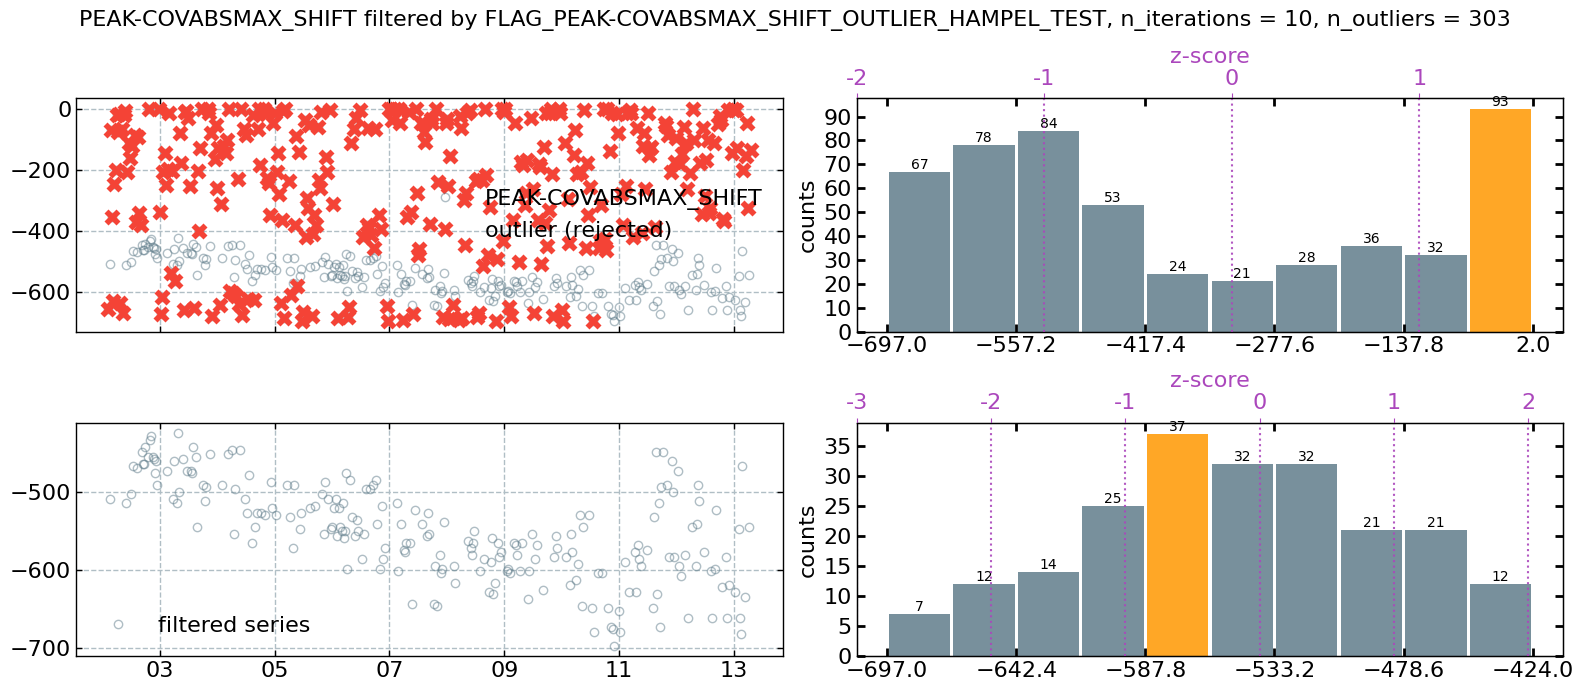

In [39]:
ham.calc(repeat=True)

In [31]:
flag = ham.get_flag()
flag

file_date
2016-11-02 02:30:00    0.0
2016-11-02 03:00:00    0.0
2016-11-02 03:30:00    0.0
2016-11-02 04:00:00    0.0
2016-11-02 04:30:00    0.0
                      ... 
2016-11-13 05:00:00    0.0
2016-11-13 05:30:00    0.0
2016-11-13 06:00:00    0.0
2016-11-13 06:30:00    0.0
2016-11-13 07:00:00    0.0
Name: FLAG_PEAK-COVABSMAX_SHIFT_OUTLIER_HAMPEL_TEST, Length: 539, dtype: float64

## Collect data
- Combine the original series, series+noise and the outlier flag

In [28]:
frame = {'s': s, 's_noise': s_noise, 'flag': flag}
checkdf = pd.DataFrame.from_dict(frame)
checkdf

NameError: name 's_noise' is not defined

## Plot

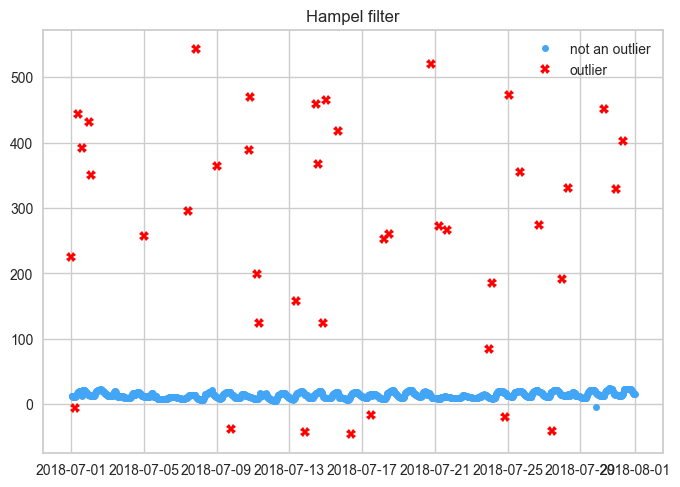

In [9]:
good_data = checkdf.loc[checkdf['flag'] == 0]['s_noise']
rejected_data = checkdf.loc[checkdf['flag'] == 2]['s_noise']

fig, ax = plt.subplots()
ax.plot(good_data, color="#42A5F5", label="not an outlier", lw=0, ms=5, marker="o")
ax.plot(rejected_data, color="red", label="outlier", lw=0, ms=7, marker="X")
plt.title("Hampel filter")
plt.legend()
plt.show()

</br>

# End of notebook

In [10]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2024-10-25 00:12:48
